In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/azartaheri/marketplace-transactions/marketplace_transactions.csv


In [10]:
# Load data
df = pd.read_csv("/kaggle/input/datasets/azartaheri/marketplace-transactions/marketplace_transactions.csv")

# Quick overview
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 18)

First 5 rows:


,transaction_id,seller_id,buyer_id,transaction_amount,item_category,transaction_date,seller_feedback_score,seller_account_age_days,num_transactions_last_7d,num_transactions_last_30d,dispute_rate,return_rate,num_policy_violations,buyer_feedback_given,login_hour,unique_items_listed,avg_item_price,is_fraud
0,TXN006253,S03594,B08065,71.50,Books,2024-05-01 05:25:00,98,2623,5,24,0.0753,0.1881,0,1,8,22,57.69,0
1,TXN004685,S02502,B03916,43.03,Books,2024-06-14 04:11:00,83,3593,9,3,0.1276,0.0369,0,1,9,22,70.23,0
2,TXN001732,S02287,B05354,347.23,Clothing,2024-02-19 15:08:00,83,287,6,8,0.0495,0.0988,0,1,22,13,100.08,0
3,TXN004743,S03043,B03653,13.56,Electronics,2024-07-09 20:27:00,92,2788,7,18,0.0717,0.0134,0,1,8,32,11.12,0
4,TXN004522,S04629,B07794,42.76,Toys,2024-07-23 16:46:00,82,2290,5,10,0.0202,0.0373,0,1,13,33,60.18,0


# Data types and non-null counts

In [11]:

print("=== Data Info ===")
print(df.info())

# Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Basic statistics
print("\n=== Basic Statistics ===")
df.describe()

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10000 non-null  object 
 1   seller_id                  10000 non-null  object 
 2   buyer_id                   10000 non-null  object 
 3   transaction_amount         10000 non-null  float64
 4   item_category              10000 non-null  object 
 5   transaction_date           10000 non-null  object 
 6   seller_feedback_score      10000 non-null  int64  
 7   seller_account_age_days    10000 non-null  int64  
 8   num_transactions_last_7d   10000 non-null  int64  
 9   num_transactions_last_30d  10000 non-null  int64  
 10  dispute_rate               10000 non-null  float64
 11  return_rate                10000 non-null  float64
 12  num_policy_violations      10000 non-null  int64  
 13  buyer_feedback_given       10

,transaction_amount,seller_feedback_score,seller_account_age_days,num_transactions_last_7d,num_transactions_last_30d,dispute_rate,return_rate,num_policy_violations,buyer_feedback_given,login_hour,unique_items_listed,avg_item_price,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,117.448590,83.406000,1729.502100,9.23600,31.54770,0.093296,0.099640,0.274800,0.750200,13.668500,50.375500,83.973657,0.100000
std,290.543786,19.662447,1106.229767,14.17593,35.26048,0.151942,0.135236,0.717451,0.432919,5.597173,87.168945,136.206650,0.300015
min,2.130000,0.000000,1.000000,1.00000,3.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.010000,0.000000
25%,32.947500,83.000000,753.000000,3.00000,13.00000,0.016400,0.020800,0.000000,1.000000,9.000000,14.000000,32.210000,0.000000
50%,59.085000,88.000000,1735.000000,6.00000,23.00000,0.039400,0.053150,0.000000,1.000000,14.000000,28.000000,53.455000,0.000000
75%,109.047500,94.000000,2682.000000,8.00000,34.00000,0.085600,0.112500,0.000000,1.000000,18.000000,42.000000,87.730000,0.000000
max,9888.790000,99.000000,3649.000000,79.00000,199.00000,0.912600,0.880000,4.000000,1.000000,23.000000,499.000000,3356.570000,1.000000


# Fraud distribution

=== Class Distribution ===
is_fraud
0    9000
1    1000
Name: count, dtype: int64

Fraud rate: 10.0%


/tmp/ipykernel_57/3672100637.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette=['steelblue','crimson'])


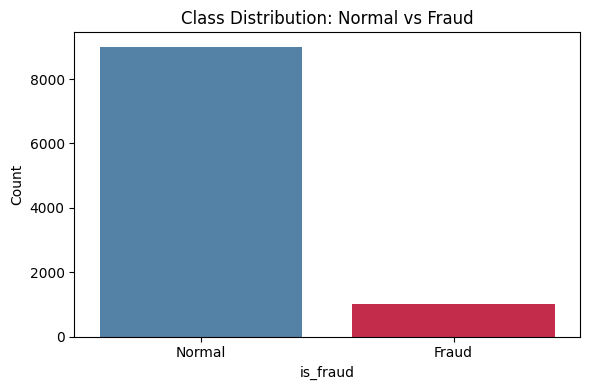

In [12]:

print("=== Class Distribution ===")
print(df['is_fraud'].value_counts())
print(f"\nFraud rate: {df['is_fraud'].mean()*100:.1f}%")

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df, palette=['steelblue','crimson'])
plt.title('Class Distribution: Normal vs Fraud')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Compare numeric features by fraud label

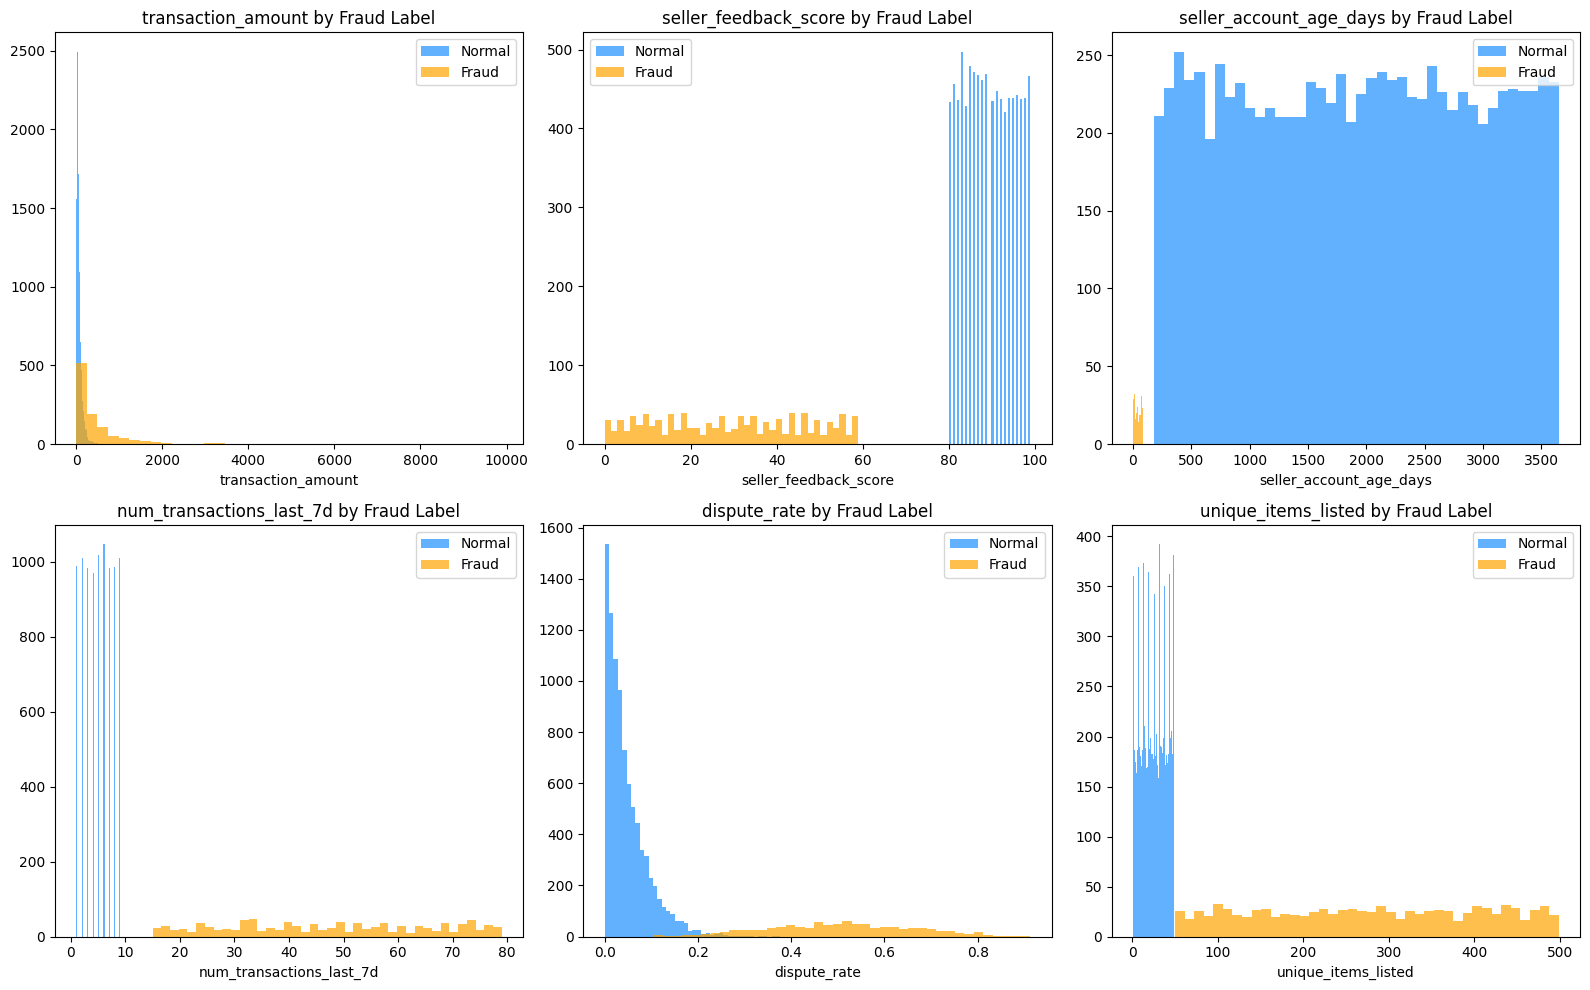

In [14]:
 
features = ['transaction_amount', 'seller_feedback_score', 
            'seller_account_age_days', 'num_transactions_last_7d',
            'dispute_rate', 'unique_items_listed']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    normal = df[df['is_fraud'] == 0][feature]
    fraud  = df[df['is_fraud'] == 1][feature]
    
    axes[i].hist(normal, bins=40, alpha=0.7, color='dodgerblue', label='Normal')
    axes[i].hist(fraud,  bins=40, alpha=0.7, color='orange',     label='Fraud')
    axes[i].set_title(f'{feature} by Fraud Label')
    axes[i].set_xlabel(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Correlation heatmap

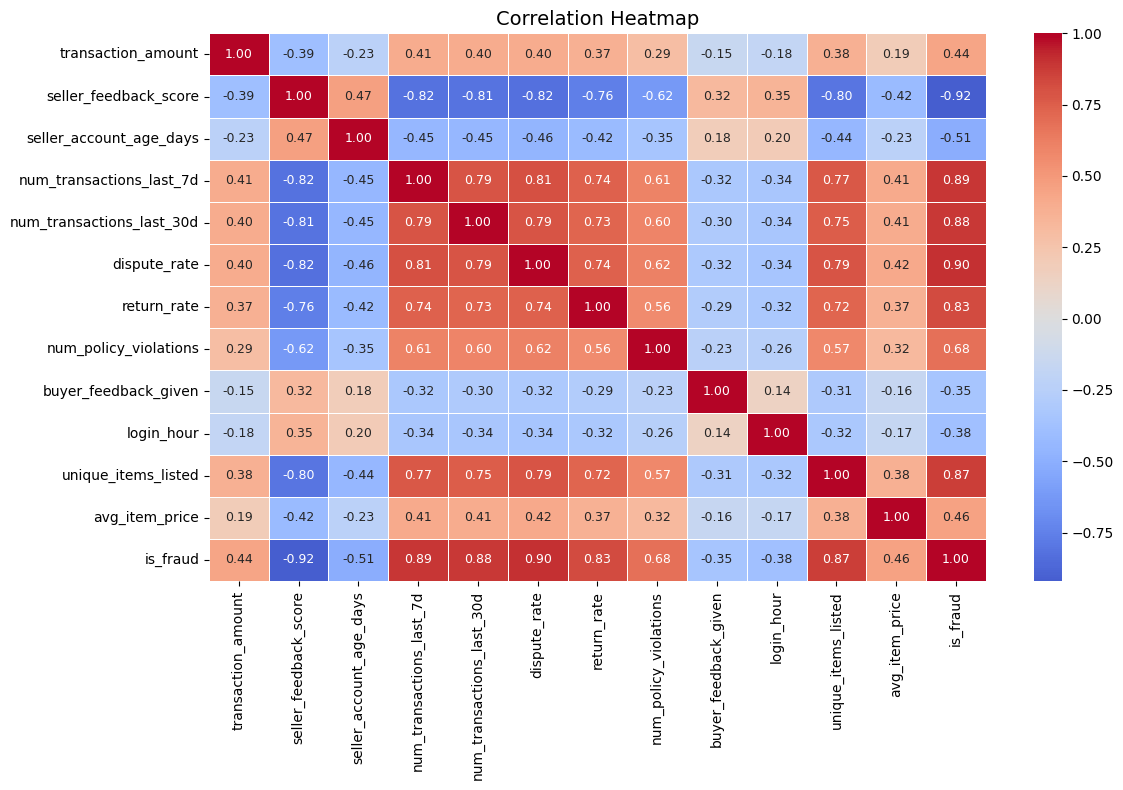

In [15]:

plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

#  Feature Engineering

In [16]:
# Parse transaction date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# 1. Velocity ratio — how concentrated recent activity is
df['velocity_ratio'] = df['num_transactions_last_7d'] / (df['num_transactions_last_30d'] + 1)

# 2. Trust score — combines feedback score and account age
df['trust_score'] = (df['seller_feedback_score'] * 0.6) + \
                    (df['seller_account_age_days'] / df['seller_account_age_days'].max() * 100 * 0.4)

# 3. Night login flag — active between 0am and 5am
df['is_night_login'] = df['login_hour'].apply(lambda x: 1 if x <= 5 else 0)

# 4. Price to feedback ratio — high price, low feedback = suspicious
df['price_to_feedback_ratio'] = df['avg_item_price'] / (df['seller_feedback_score'] + 1)

# 5. Dispute & return combined risk score
df['risk_score'] = df['dispute_rate'] * 0.5 + df['return_rate'] * 0.5

# 6. Listing intensity — items listed relative to account age
df['listing_intensity'] = df['unique_items_listed'] / (df['seller_account_age_days'] + 1)

# Confirm new features
print("New features added:")
new_features = ['velocity_ratio', 'trust_score', 'is_night_login', 
                'price_to_feedback_ratio', 'risk_score', 'listing_intensity']
print(df[new_features].describe().round(3))

New features added:
       velocity_ratio  trust_score  is_night_login  price_to_feedback_ratio  \
count       10000.000    10000.000       10000.000                10000.000   
mean            0.336       69.002           0.076                    2.688   
std             0.323       20.482           0.265                   19.470   
min             0.025        0.033           0.000                    0.036   
25%             0.133       61.924           0.000                    0.359   
50%             0.241       72.547           0.000                    0.604   
75%             0.417       83.204           0.000                    1.028   
max             2.250       99.356           1.000                  800.725   

       risk_score  listing_intensity  
count   10000.000          10000.000  
mean        0.096              1.355  
std         0.134              8.369  
min         0.000              0.000  
25%         0.029              0.007  
50%         0.052              0.0

# Prepare Data for Modeling

In [17]:
from sklearn.preprocessing import StandardScaler

# Select features for modeling (drop IDs, date, and label)
feature_cols = [
    'transaction_amount', 'seller_feedback_score', 'seller_account_age_days',
    'num_transactions_last_7d', 'num_transactions_last_30d', 'dispute_rate',
    'return_rate', 'num_policy_violations', 'buyer_feedback_given',
    'login_hour', 'unique_items_listed', 'avg_item_price',
    'velocity_ratio', 'trust_score', 'is_night_login',
    'price_to_feedback_ratio', 'risk_score', 'listing_intensity'
]

X = df[feature_cols]
y = df['is_fraud']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features shape: {X_scaled.shape}")
print(f"Fraud cases: {y.sum()} | Normal cases: {(y==0).sum()}")

Features shape: (10000, 18)
Fraud cases: 1000 | Normal cases: 9000


# Model 1: Z-Score (Statistical Baseline)

=== Z-Score Anomaly Detection ===
Flagged as anomaly: 1231

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99      9000
       Fraud       0.81      0.99      0.89      1000

    accuracy                           0.98     10000
   macro avg       0.90      0.98      0.94     10000
weighted avg       0.98      0.98      0.98     10000



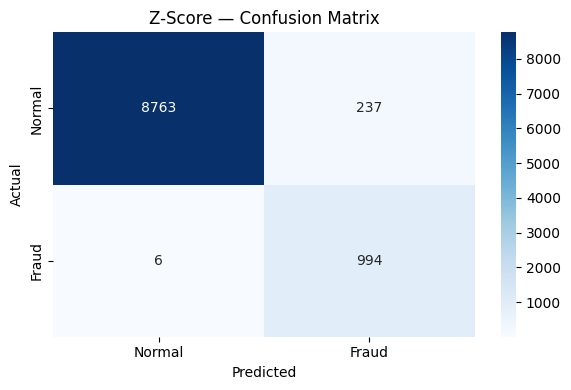

In [18]:
from scipy import stats

# Calculate Z-scores for each feature
z_scores = np.abs(stats.zscore(X_scaled))

# Flag a transaction as anomaly if ANY feature has Z-score > 3
z_anomaly = (z_scores > 3).any(axis=1).astype(int)

# Evaluate against true labels
from sklearn.metrics import classification_report, confusion_matrix

print("=== Z-Score Anomaly Detection ===")
print(f"Flagged as anomaly: {z_anomaly.sum()}")
print(f"\nClassification Report:")
print(classification_report(y, z_anomaly, target_names=['Normal', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y, z_anomaly)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Z-Score — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Model 2: Isolation Forest

=== Isolation Forest Anomaly Detection ===
Flagged as anomaly: 1000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9000
       Fraud       1.00      1.00      1.00      1000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



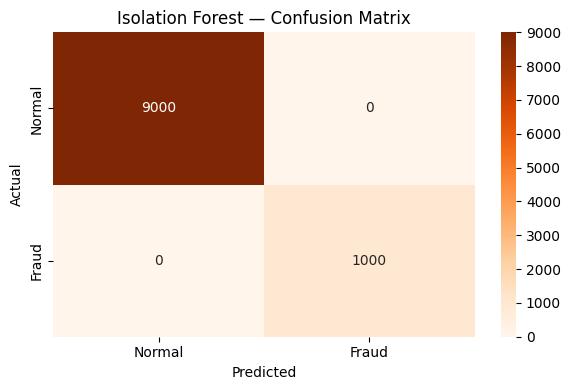

In [19]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.10,  # we know fraud rate is 10%
    random_state=42
)
iso_pred = iso_forest.fit_predict(X_scaled)

# Convert: Isolation Forest returns -1 for anomaly, 1 for normal
iso_anomaly = (iso_pred == -1).astype(int)

# Evaluate
print("=== Isolation Forest Anomaly Detection ===")
print(f"Flagged as anomaly: {iso_anomaly.sum()}")
print(f"\nClassification Report:")
print(classification_report(y, iso_anomaly, target_names=['Normal', 'Fraud']))

# Confusion matrix
cm2 = confusion_matrix(y, iso_anomaly)
plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Isolation Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Model 3: DBSCAN

=== DBSCAN Anomaly Detection ===
Flagged as anomaly: 1090

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      9000
       Fraud       0.92      1.00      0.96      1000

    accuracy                           0.99     10000
   macro avg       0.96      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



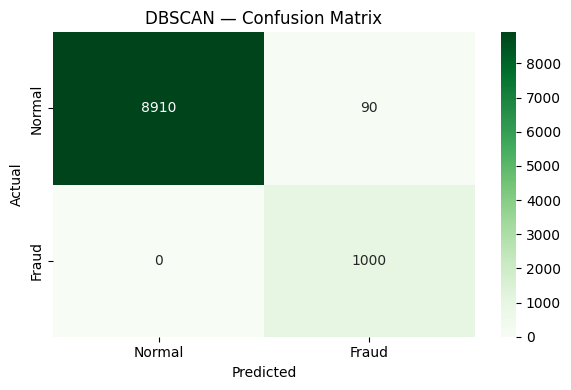

In [20]:
from sklearn.cluster import DBSCAN

# Train DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_pred = dbscan.fit_predict(X_scaled)

# Points labeled -1 are outliers = anomalies
dbscan_anomaly = (db_pred == -1).astype(int)

# Evaluate
print("=== DBSCAN Anomaly Detection ===")
print(f"Flagged as anomaly: {dbscan_anomaly.sum()}")
print(f"\nClassification Report:")
print(classification_report(y, dbscan_anomaly, target_names=['Normal', 'Fraud']))

# Confusion matrix
cm3 = confusion_matrix(y, dbscan_anomaly)
plt.figure(figsize=(6,4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('DBSCAN — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Model comparison data

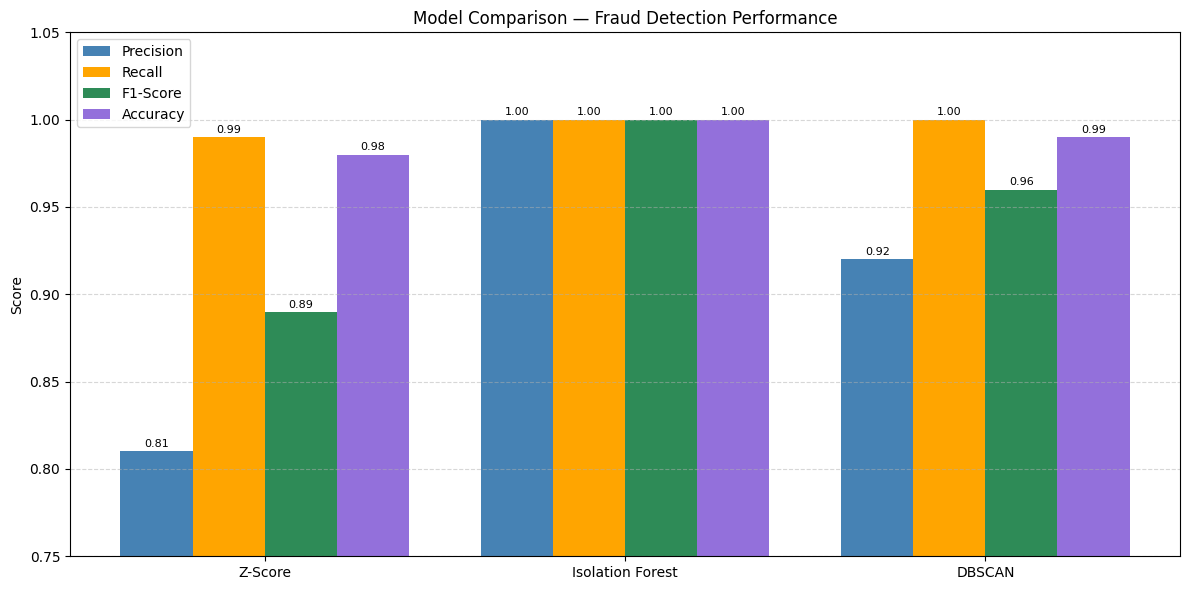

In [21]:
# Model comparison data
models = ['Z-Score', 'Isolation Forest', 'DBSCAN']
precision = [0.81, 1.00, 0.92]
recall    = [0.99, 1.00, 1.00]
f1        = [0.89, 1.00, 0.96]
accuracy  = [0.98, 1.00, 0.99]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='steelblue')
bars2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='orange')
bars3 = ax.bar(x + 0.5*width, f1,        width, label='F1-Score',  color='seagreen')
bars4 = ax.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color='mediumpurple')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Fraud Detection Performance')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.75, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

plt.tight_layout()
plt.show()

#  Anomaly Score Distribution

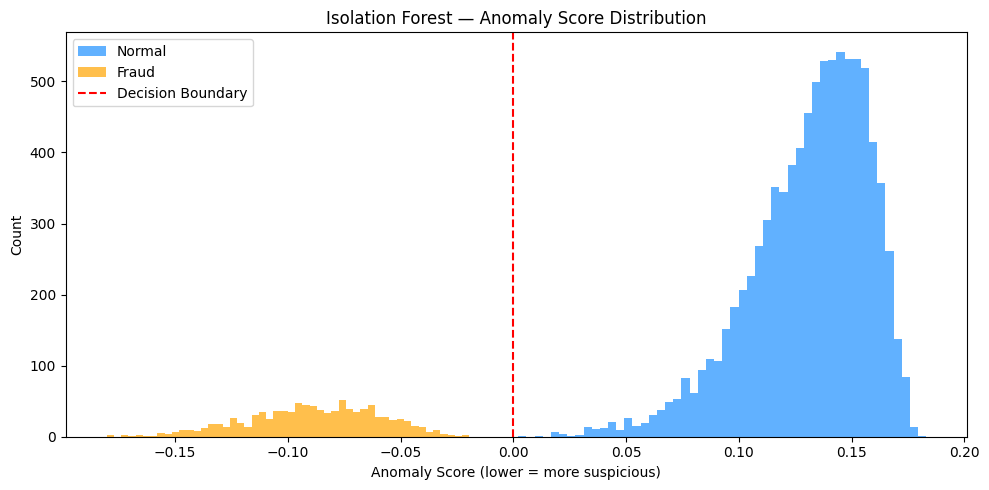

In [22]:
# Get anomaly scores from Isolation Forest (more negative = more anomalous)
anomaly_scores = iso_forest.decision_function(X_scaled)

plt.figure(figsize=(10, 5))
plt.hist(anomaly_scores[y == 0], bins=50, alpha=0.7, 
         color='dodgerblue', label='Normal')
plt.hist(anomaly_scores[y == 1], bins=50, alpha=0.7, 
         color='orange', label='Fraud')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary')
plt.title('Isolation Forest — Anomaly Score Distribution')
plt.xlabel('Anomaly Score (lower = more suspicious)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance from Isolation Forest


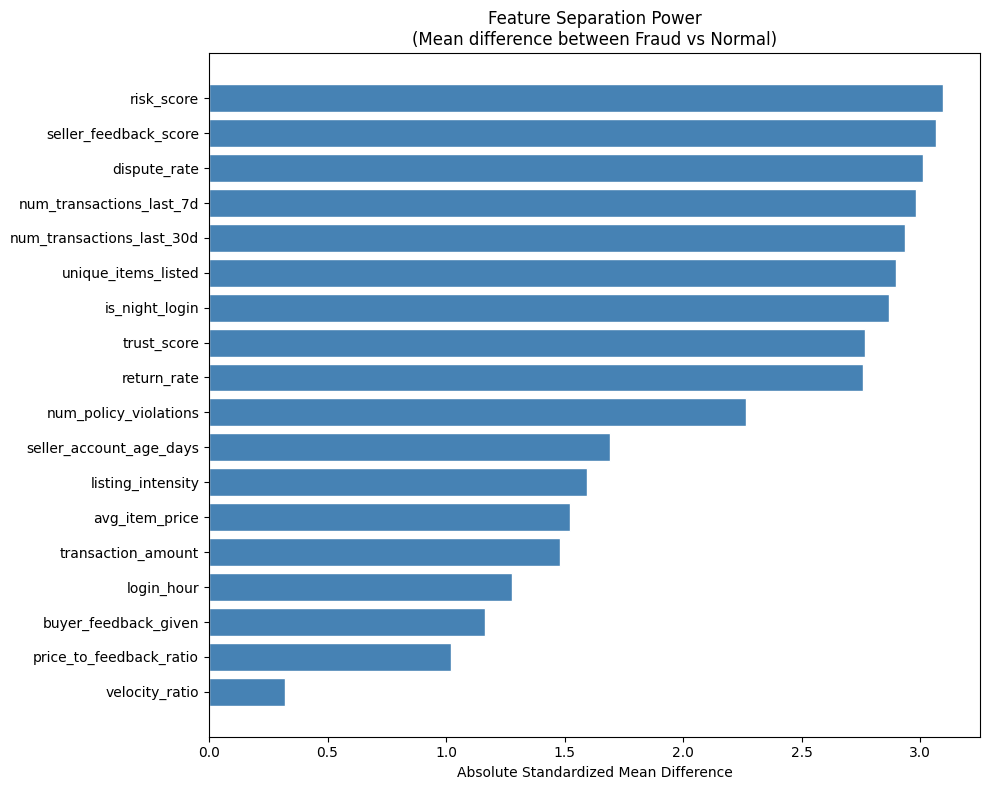

In [26]:
# Compare mean feature values between fraud and normal
# Higher difference = more important for separating fraud

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'normal_mean': X_scaled[y == 0].mean(axis=0),
    'fraud_mean':  X_scaled[y == 1].mean(axis=0)
})

importance_df['separation'] = np.abs(
    importance_df['fraud_mean'] - importance_df['normal_mean']
).round(3)

importance_df = importance_df.sort_values('separation', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['separation'],
         color='steelblue', edgecolor='white')
plt.title('Feature Separation Power\n(Mean difference between Fraud vs Normal)')
plt.xlabel('Absolute Standardized Mean Difference')
plt.tight_layout()
plt.show()

In [27]:
summary = pd.DataFrame({
    'Model':           ['Z-Score', 'Isolation Forest', 'DBSCAN'],
    'Precision':       [0.81, 1.00, 0.92],
    'Recall':          [0.99, 1.00, 1.00],
    'F1-Score':        [0.89, 1.00, 0.96],
    'Accuracy':        [0.98, 1.00, 0.99],
    'False Positives': [237,  0,    90],
    'Winner':          ['','✅ Best','']
})

print("=== Final Model Comparison ===")
print(summary.to_string(index=False))

=== Final Model Comparison ===
           Model  Precision  Recall  F1-Score  Accuracy  False Positives Winner
         Z-Score       0.81    0.99      0.89      0.98              237       
Isolation Forest       1.00    1.00      1.00      1.00                0 ✅ Best
          DBSCAN       0.92    1.00      0.96      0.99               90       
